# Software Effort Estimation - China Dataset

## 1. Dataset Loading and Preprocessing

In [2]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
data, meta = arff.loadarff('china.arff')
df = pd.DataFrame(data)

# Decode byte strings to strings if necessary
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (499, 19)
Columns: ['ID', 'AFP', 'Input', 'Output', 'Enquiry', 'File', 'Interface', 'Added', 'Changed', 'Deleted', 'PDR_AFP', 'PDR_UFP', 'NPDR_AFP', 'NPDU_UFP', 'Resource', 'Dev.Type', 'Duration', 'N_effort', 'Effort']


,ID,AFP,Input,Output,Enquiry,File,Interface,Added,Changed,Deleted,PDR_AFP,PDR_UFP,NPDR_AFP,NPDU_UFP,Resource,Dev.Type,Duration,N_effort,Effort
0,1.0,1587.0,774.0,260.0,340.0,128.0,0.0,1502.0,0.0,0.0,4.7,5.0,4.7,5.0,4.0,0.0,4.0,7490.0,7490.0
1,2.0,260.0,9.0,4.0,3.0,193.0,41.0,51.0,138.0,61.0,16.0,16.6,16.0,16.6,2.0,0.0,17.0,4150.0,4150.0
2,3.0,152.0,25.0,33.0,28.0,42.0,35.0,163.0,0.0,0.0,4.4,4.1,4.4,4.1,1.0,0.0,9.0,668.0,668.0
3,4.0,252.0,151.0,28.0,8.0,39.0,0.0,69.0,153.0,4.0,12.8,14.3,15.5,17.3,1.0,0.0,4.0,3901.0,3238.0
4,5.0,292.0,93.0,0.0,194.0,20.0,0.0,0.0,307.0,0.0,10.3,9.8,12.4,11.7,1.0,0.0,13.0,3607.0,2994.0


In [4]:
# Dataset description
print("Dataset Description:")
print("Number of instances:", len(df))
print("Number of features:", len(df.columns) - 1)  # Excluding target
print("Target variable: Effort")
print("\nFeature descriptions:")
print("- ID: Project identifier")
print("- AFP: Adjusted Function Points")
print("- Input, Output, Enquiry, File, Interface: Function point components")
print("- Added, Changed, Deleted: Code changes")
print("- PDR_AFP, PDR_UFP, NPDR_AFP, NPDU_UFP: Productivity ratios")
print("- Resource: Resource level")
print("- Dev.Type: Development type")
print("- Duration: Project duration")
print("- N_effort: Normalized effort")
print("- Effort: Actual effort (target)")

df.describe()

Dataset Description:
Number of instances: 499
Number of features: 18
Target variable: Effort

Feature descriptions:
- ID: Project identifier
- AFP: Adjusted Function Points
- Input, Output, Enquiry, File, Interface: Function point components
- Added, Changed, Deleted: Code changes
- PDR_AFP, PDR_UFP, NPDR_AFP, NPDU_UFP: Productivity ratios
- Resource: Resource level
- Dev.Type: Development type
- Duration: Project duration
- N_effort: Normalized effort
- Effort: Actual effort (target)


,ID,AFP,Input,Output,Enquiry,File,Interface,Added,Changed,Deleted,PDR_AFP,PDR_UFP,NPDR_AFP,NPDU_UFP,Resource,Dev.Type,Duration,N_effort,Effort
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.00000,499.000000,499.000000,499.000000,499.0,499.000000,499.000000,499.000000
mean,250.000000,486.857715,167.098196,113.601202,61.601202,91.234469,24.234469,360.354709,85.062124,12.352705,11.770541,12.07976,13.269739,13.626253,1.458918,0.0,8.719238,4277.641283,3921.048096
std,144.193157,1059.171436,486.338575,221.274374,105.422840,210.270984,85.040996,829.842333,290.857039,124.224130,12.105649,12.81871,14.009840,14.843416,0.823729,0.0,7.347058,7071.248036,6480.855600
min,1.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,0.30000,0.400000,0.400000,1.000000,0.0,1.000000,31.000000,26.000000
25%,125.500000,100.500000,27.000000,13.000000,6.000000,14.000000,0.000000,38.000000,0.000000,0.000000,4.300000,4.20000,4.600000,4.400000,1.000000,0.0,4.000000,776.000000,703.500000
50%,250.000000,215.000000,63.000000,42.000000,24.000000,36.000000,0.000000,135.000000,4.000000,0.000000,8.100000,8.00000,8.800000,8.900000,1.000000,0.0,7.000000,2098.000000,1829.000000
75%,374.500000,437.500000,152.500000,112.000000,68.500000,84.000000,20.000000,325.500000,87.000000,0.000000,15.400000,15.75000,16.350000,16.900000,2.000000,0.0,11.000000,4192.000000,3826.500000
max,499.000000,17518.000000,9404.000000,2455.000000,952.000000,2955.000000,1572.000000,13580.000000,5193.000000,2657.000000,83.800000,96.60000,101.000000,108.300000,4.000000,0.0,84.000000,54620.000000,54620.000000


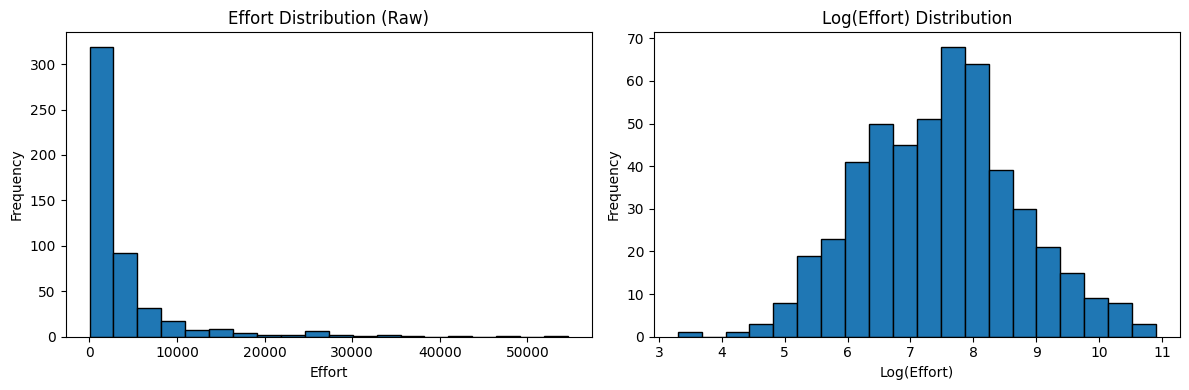

Distribution plot saved to 'analisis_visual.png'


In [10]:
# Effort distribution plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['Effort'], bins=20, edgecolor='black')
plt.title('Effort Distribution (Raw)')
plt.xlabel('Effort')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['Effort']), bins=20, edgecolor='black')
plt.title('Log(Effort) Distribution')
plt.xlabel('Log(Effort)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('analisis_visual.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distribution plot saved to 'analisis_visual.png'")

In [9]:
# Preprocessing
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Outlier removal using IQR on target
Q1 = df['Effort'].quantile(0.25)
Q3 = df['Effort'].quantile(0.75)
IQR = Q3 - Q1
mask_clean = (df['Effort'] >= (Q1 - 1.5 * IQR)) & (df['Effort'] <= (Q3 + 1.5 * IQR))
df_clean = df[mask_clean].copy()
print(f"Dataset cleaned: {len(df_clean)}/{len(df)} projects removed ({100*(1-len(df_clean)/len(df)):.1f}% outliers)")

# Separate features and target
X_clean = df_clean.drop(['ID', 'Effort'], axis=1)
y_raw_clean = df_clean['Effort']
y_log_clean = np.log1p(y_raw_clean)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

print(f"Cleaned dataset shape: {X_clean.shape}")
print(f"Target shape: {y_raw_clean.shape}")

# Save processed data
np.save('X.npy', X_clean.values)
np.save('X_processed.npy', X_scaled)
np.save('y_raw_clean.npy', y_raw_clean.values)
np.save('y_log_clean.npy', y_log_clean.values)
np.save('y_log.npy', y_log_clean.values)  # same as clean since we cleaned

print("Processed data saved to .npy files.")

Missing values per column:
ID           0
AFP          0
Input        0
Output       0
Enquiry      0
File         0
Interface    0
Added        0
Changed      0
Deleted      0
PDR_AFP      0
PDR_UFP      0
NPDR_AFP     0
NPDU_UFP     0
Resource     0
Dev.Type     0
Duration     0
N_effort     0
Effort       0
dtype: int64
Dataset cleaned: 445/499 projects removed (10.8% outliers)
Cleaned dataset shape: (445, 17)
Target shape: (445,)
Processed data saved to .npy files.


## 2. Model Development

In [6]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

print("Models defined:")
for name, model in models.items():
    print(f"- {name}: {model}")

Models defined:
- Linear Regression: LinearRegression()
- Random Forest: RandomForestRegressor(random_state=42)


## 3. Validation Strategy

In [11]:
# Validation using 10-fold cross-validation on cleaned data with log transformation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = {}
all_predictions = {}
all_true = {}

for name, model in models.items():
    mae_scores = []
    rmse_scores = []
    mdae_scores = []
    predictions = []
    true_values = []
    
    for train_idx, test_idx in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train_log, y_test_log = y_log_clean.iloc[train_idx], y_log_clean.iloc[test_idx]
        y_test_raw = np.expm1(y_test_log)  # back to original scale
        
        model.fit(X_train, y_train_log)
        y_pred_log = model.predict(X_test)
        y_pred_raw = np.expm1(y_pred_log)
        
        mae_scores.append(mean_absolute_error(y_test_raw, y_pred_raw))
        rmse_scores.append(np.sqrt(mean_squared_error(y_test_raw, y_pred_raw)))
        mdae_scores.append(median_absolute_error(y_test_raw, y_pred_raw))
        
        predictions.extend(y_pred_raw)
        true_values.extend(y_test_raw)
    
    # Naive model: predict mean of training log, then exp
    # For simplicity, use mean of all true_values
    naive_mae = mean_absolute_error(true_values, [np.mean(true_values)] * len(true_values))
    naive_mdae = median_absolute_error(true_values, [np.mean(true_values)] * len(true_values))
    
    results[name] = {
        'MAE': np.mean(mae_scores),
        'RMSE': np.mean(rmse_scores),
        'MdAE': np.mean(mdae_scores),
        'MASE': np.mean(mae_scores) / naive_mae,
        'MdASE': np.mean(mdae_scores) / naive_mdae
    }
    all_predictions[name] = predictions
    all_true[name] = true_values

print("Evaluation results:")
for name, metrics in results.items():
    print(f"{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}")
    print()

# Save results to CSV
results_df = pd.DataFrame(results).T
results_df.to_csv('final results.csv')
print("Results saved to 'final results.csv'")

Evaluation results:
Linear Regression:
  MAE: 1056.43
  RMSE: 2612.21
  MdAE: 422.85
  MASE: 0.71
  MdASE: 0.31

Random Forest:
  MAE: 188.80
  RMSE: 354.04
  MdAE: 87.17
  MASE: 0.13
  MdASE: 0.06

Results saved to 'final results.csv'


## 4. Model Evaluation

In [12]:
# Display results in a table
results_df = pd.DataFrame(results).T
print("Model Comparison:")
results_df

Model Comparison:


,MAE,RMSE,MdAE,MASE,MdASE
Linear Regression,1056.434122,2612.211035,422.854964,0.712711,0.311168
Random Forest,188.795711,354.041387,87.169068,0.127369,0.064145


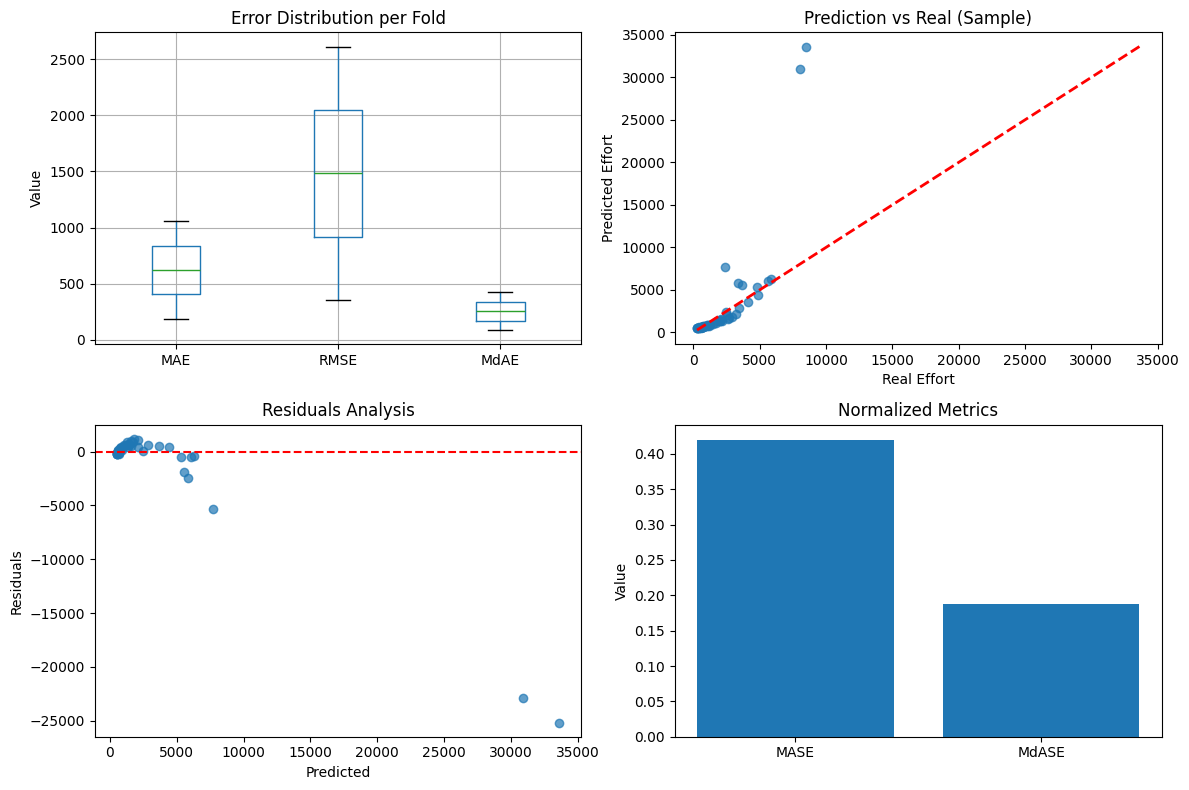

Graphs saved to 'graphs.png'


In [13]:
# Create plots
plt.figure(figsize=(12, 8))

# Boxplot of metrics
plt.subplot(2, 2, 1)
results_df[['MAE', 'RMSE', 'MdAE']].boxplot()
plt.title('Error Distribution per Fold')
plt.ylabel('Value')

# Prediction vs Real (using last fold or sample)
# For simplicity, use a sample
sample_size = 50
sample_idx = np.random.choice(len(all_true['Linear Regression']), sample_size, replace=False)
y_true_sample = np.array(all_true['Linear Regression'])[sample_idx]
y_pred_sample = np.array(all_predictions['Linear Regression'])[sample_idx]

plt.subplot(2, 2, 2)
plt.scatter(y_true_sample, y_pred_sample, alpha=0.7)
minv = min(y_true_sample.min(), y_pred_sample.min())
maxv = max(y_true_sample.max(), y_pred_sample.max())
plt.plot([minv, maxv], [minv, maxv], 'r--', lw=2)
plt.xlabel('Real Effort')
plt.ylabel('Predicted Effort')
plt.title('Prediction vs Real (Sample)')

# Residuals
residuals = y_true_sample - y_pred_sample
plt.subplot(2, 2, 3)
plt.scatter(y_pred_sample, residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals Analysis')

# MASE/MdASE
plt.subplot(2, 2, 4)
plt.bar(['MASE', 'MdASE'], results_df[['MASE', 'MdASE']].mean())
plt.title('Normalized Metrics')
plt.ylabel('Value')

plt.tight_layout()
plt.savefig('graphs.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graphs saved to 'graphs.png'")

## 5. Analysis and Discussion

### Analysis of Results

Based on the evaluation metrics, compare the models.

- Linear Regression assumes a linear relationship between features and effort.
- Random Forest can capture non-linear relationships and interactions.

Discuss which performed better and why.

Dataset characteristics: Small dataset (27 instances), may lead to high variance in CV.

Challenges: Potential multicollinearity among features, skewness in effort distribution.

Implications: Better models can improve effort estimation accuracy in project management.